**PROJECT TITLE: ONLINE SHOPPING BEHAVIOUR ANALYSIS USING MACHINE LEARNING**

**Introduction:**

Online shopping has become an essential part of modern life due to the growth of e-commerce platforms. Customers interact with online systems through browsing, comparing, and purchasing products, generating valuable data. Analysing this data helps in understanding customer behaviour and improving business strategies. This project focuses on using machine learning techniques to predict whether a customer will purchase a product or not based on different influencing factors.

 **Objectives:**

The main objective of this project is to analyse customer behaviour in online shopping and predict purchase decisions using machine learning models. It also aims to preprocess collected data, apply multiple classification algorithms, evaluate their performance using K-Fold Cross Validation, and present the results through a user-friendly Streamlit web application.

 **Problems:**

Predicting customer purchase behaviour is challenging due to multiple influencing factors such as pricing, product ratings, brand reputation, and personal preferences. Traditional analysis methods are not efficient for handling large and complex datasets. Additionally, manually collected data may contain inconsistencies, missing values, and limited samples, which can affect model accuracy and reliability.

 **Solutions:**

To address these challenges, machine learning techniques are used to analyse and predict customer behaviour effectively. Data preprocessing is performed to clean and transform the dataset. Multiple models such as Logistic Regression, Decision Tree, and KNN are applied and evaluated using K-Fold Cross Validation. An ensemble model is used to improve accuracy. Finally, a Streamlit web application is developed to present results through visualization and voice output, making the system interactive and easy to use.

**1. Importing Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import re

**2. Loading the Dataset**

In [ ]:
cr = pd.read_csv("Online Shopping Behavior Survey  (Responses) - Form Responses 1.csv")

**3. Understanding the Dataset**

In [ ]:
print("Original rows:", len(cr))

Original rows: 52


In [ ]:
print(cr.columns)

Index(['Timestamp', 'Name', '  Age Group  ', '   Gender  ',
       '  Average Monthly Spending on Online Shopping (INR)  ',
       '  Purchase Frequency  ',
       '  Return Rate of Purchased Items (%) eg : 10 , 25 ,  50',
       '  Device(s) Used for Online Shopping  ',
       '  Preferred E-Commerce Platform(s)  ',
       '  Preferred Payment Method(s)  ',
       '  Most Frequently Purchased Product Category  ',
       '  How much do discounts influence your purchase decision?  ',
       '  What discount range usually convinces you to buy?  ',
       '  Which factors influence your purchase decision?  ',
       '  Minimum Product Rating You Consider Before Purchasing  ',
       '  Do product images/videos affect your decision?  ',
       '  Any specific reason you decide NOT to purchase a product?  ',
       '  Based on the above factors, would you complete the purchase?  '],
      dtype='object')


In [ ]:
cr.columns = cr.columns.str.strip()

In [ ]:
cr.rename(columns={
"Age Group": "Age_Group",
"Gender": "Gender",
"Average Monthly Spending on Online Shopping (INR)": "Monthly_Spending",
"Purchase Frequency": "Purchase_Frequency",
"Return Rate of Purchased Items (%) eg : 10 , 25 ,  50": "Return_Rate",
"Device(s) Used for Online Shopping": "Device",
"Preferred E-Commerce Platform(s)": "Platform",
"Preferred Payment Method(s)": "Payment_Method",
"Most Frequently Purchased Product Category": "Product_Category",
"How much do discounts influence your purchase decision?": "Discount_Influence",
"What discount range usually convinces you to buy?": "Discount_Range",
"Which factors influence your purchase decision?": "Purchase_Factors",
"Minimum Product Rating You Consider Before Purchasing": "Min_Rating",
"Do product images/videos affect your decision?": "Media_Influence",
"Any specific reason you decide NOT to purchase a product?": "No_Purchase_Reason",
"Based on the above factors, would you complete the purchase?": "Purchase_Decision"
}, inplace=True)

**4. Data Preprocessing**

In [ ]:
cr.isnull().sum()

,0
Timestamp,0
Name,0
Age_Group,0
Gender,1
Monthly_Spending,0
Purchase_Frequency,0
Return_Rate,0
Device,0
Platform,0
Payment_Method,0


In [ ]:
cr["Gender"].fillna(cr["Gender"].mode()[0], inplace=True)

/tmp/ipykernel_14899/3568646927.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Gender"].fillna(cr["Gender"].mode()[0], inplace=True)


In [ ]:
cr["No_Purchase_Reason"].fillna("No reason provided", inplace=True)

/tmp/ipykernel_14899/2624311325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["No_Purchase_Reason"].fillna("No reason provided", inplace=True)


In [ ]:
cr.isnull().sum()

,0
Timestamp,0
Name,0
Age_Group,0
Gender,0
Monthly_Spending,0
Purchase_Frequency,0
Return_Rate,0
Device,0
Platform,0
Payment_Method,0


In [ ]:
cr["Age_Group"].replace({
"19–30":0,
"31–50":1,
"57":2,
"18":3,
"22":4,
"13":5,
"15":6

}, inplace=True)

/tmp/ipykernel_14899/1783364049.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Age_Group"].replace({


In [ ]:
cr["Gender"].replace({
"Male":0,
"Female":1,
"Prefer not to say":2
}, inplace=True)

/tmp/ipykernel_14899/4223976720.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Gender"].replace({


In [ ]:
cr["Monthly_Spending"].replace({
"₹1,000 – ₹5,000":0,
"₹5,000 – ₹10,000":1,
"₹10,000+":2
}, inplace=True)

/tmp/ipykernel_14899/396820130.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Monthly_Spending"].replace({
/tmp/ipykernel_14899/396820130.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Monthly_Spending"].replace({


In [ ]:
cr["Purchase_Frequency"].replace({
"Daily":0,
"Weekly":1,
"Monthly":2
}, inplace=True)

/tmp/ipykernel_14899/1073007681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Purchase_Frequency"].replace({
/tmp/ipykernel_14899/1073007681.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Purchase_Frequency"].replace({


In [ ]:
cr["Product_Category"].replace({
"Electronics":0,
"Clothing":1,
"Groceries":2,
"Footwear":3,
"Home Appliances":4,
"House needs - utensils, and cleaning stuffs":5,
"Skin care ":6,
"Skin care":7,
"All ":8,
"skin care products":9,
"Gift items ":10
}, inplace=True)

/tmp/ipykernel_14899/2032790260.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Product_Category"].replace({
/tmp/ipykernel_14899/2032790260.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Product_Category"].replace({


In [ ]:
cr["Discount_Influence"].replace({
"Not at all":0,
"Slightly":1,
"Moderately":2,
"Very much":3,
"Extremely":4
}, inplace=True)

/tmp/ipykernel_14899/1247861489.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Discount_Influence"].replace({
/tmp/ipykernel_14899/1247861489.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Discount_Influence"].replace({


In [ ]:
cr["Discount_Range"].replace({
"Below 10%":0,
"10% – 30%":1,
"30% – 50%":2,
"Above 50%":3
}, inplace=True)

/tmp/ipykernel_14899/3260972699.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Discount_Range"].replace({
/tmp/ipykernel_14899/3260972699.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Discount_Range"].replace({


In [ ]:
cr["Min_Rating"].replace({
"2 ⭐":2,
"3 ⭐":3,
"4 ⭐":4,
"5 ⭐":5
}, inplace=True)

/tmp/ipykernel_14899/1951245686.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Min_Rating"].replace({
/tmp/ipykernel_14899/1951245686.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Min_Rating"].replace({


In [ ]:
cr["Media_Influence"].replace({
"Yes":1,
"No":0
}, inplace=True)

/tmp/ipykernel_14899/3946645610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Media_Influence"].replace({
/tmp/ipykernel_14899/3946645610.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Media_Influence"].replace({


In [ ]:
cr["Purchase_Decision"].replace({
"Yes":1,
"No":0
}, inplace=True)

/tmp/ipykernel_14899/3016719929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Purchase_Decision"].replace({
/tmp/ipykernel_14899/3016719929.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Purchase_Decision"].replace({


In [ ]:
cr["Payment_Method"].replace({
"UPI":0,
"Cash on Delivery":1,
"Credit / Debit Card":2,
"Net Banking":3
}, inplace=True)

/tmp/ipykernel_14899/3488762325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Payment_Method"].replace({
/tmp/ipykernel_14899/3488762325.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cr["Payment_Method"].replace({


In [ ]:
device = cr["Device"].str.get_dummies(sep=",")
cr = pd.concat([cr, device], axis=1)

In [ ]:
platform = cr["Platform"].str.get_dummies(sep=",")
cr = pd.concat([cr, platform], axis=1)

In [ ]:
factors = cr["Purchase_Factors"].str.get_dummies(sep=",")
cr = pd.concat([cr, factors], axis=1)

In [ ]:
# Clean Return_Rate column

# Step 1: Replace known text values
cr["Return_Rate"].replace({
    "Nil": 0,
    "Not always a considerable factor": 0,
    "Less than 10%": 5,
    "1or2": 2,
    "10no": 10,
    "70-80": 75
}, inplace=True)

# Step 2: Remove percentage symbol
cr["Return_Rate"] = cr["Return_Rate"].astype(str).str.replace("%", "")

# Step 3: Convert column to numeric
cr["Return_Rate"] = pd.to_numeric(cr["Return_Rate"], errors="coerce")

# Step 4: Fill missing values with median
cr["Return_Rate"].fillna(cr["Return_Rate"].median(), inplace=True)

# Step 5: Check cleaned values
print(cr["Return_Rate"].unique())

[  0   5  25  10   2  15  20   1  75  50 100]


/tmp/ipykernel_14899/2353648719.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr["Return_Rate"].replace({
/tmp/ipykernel_14899/2353648719.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({

In [ ]:
cr["Return_Rate"].unique()

array([  0,   5,  25,  10,   2,  15,  20,   1,  75,  50, 100])

In [ ]:
cr.drop(["Device","Platform","Purchase_Factors"], axis=1, inplace=True)

In [ ]:
cr.head(12)

,Timestamp,Name,Age_Group,Gender,Monthly_Spending,Purchase_Frequency,Return_Rate,Payment_Method,Product_Category,Discount_Influence,...,Myntra,Nykaa,Brand reputation,Price,Ratings,Return policy,Brand reputation,Price,Product reviews,Ratings
0,02-03-2026 21:10,Sherin.V,0,1,0,2,0,1,9,3,...,0,0,1,1,1,0,0,0,1,0
1,02-03-2026 22:12,Immanuel pm,1,0,2,1,5,2,2,2,...,0,0,1,1,0,0,0,0,0,1
2,02-03-2026 22:12,Harishma R,0,1,0,2,5,1,1,2,...,0,0,0,0,0,0,0,0,1,0
3,02-03-2026 22:14,Deboral,0,1,0,2,25,0,1,1,...,1,0,0,0,0,0,0,0,1,0
4,02-03-2026 22:17,R.Gomathy,1,1,0,2,10,0,4,3,...,0,0,0,0,0,0,0,0,1,0
5,02-03-2026 22:17,Akshaya,0,1,0,2,10,0,1,2,...,0,0,1,0,1,0,0,0,1,0
6,02-03-2026 22:22,L John Britto,1,0,0,2,10,0,0,2,...,0,0,1,0,0,0,0,0,0,1
7,02-03-2026 22:33,SANDHYA YS,0,1,0,1,25,0,1,3,...,0,0,1,1,1,0,0,0,1,0
8,02-03-2026 22:36,Sherin mary,0,1,0,2,10,0,1,3,...,0,0,0,0,0,0,1,0,0,0
9,02-03-2026 22:40,NIHILA,1,1,0,2,10,0,4,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
cr.columns

Index(['Timestamp', 'Name', 'Age_Group', 'Gender', 'Monthly_Spending',
       'Purchase_Frequency', 'Return_Rate', 'Payment_Method',
       'Product_Category', 'Discount_Influence', 'Discount_Range',
       'Min_Rating', 'Media_Influence', 'No_Purchase_Reason',
       'Purchase_Decision', ' Desktop', ' Laptop', ' Tablet', 'Desktop',
       'Mobile', 'Tablet', ' Ajio', ' Cred', ' Flipkart',
       ' Instagram platforms', ' Meesho', ' Myntra', ' Nykaa',
       ' Online dealers', ' big basket', ' purple', 'Amazon', 'Flipkart',
       'Meesho', 'Myntra', 'Nykaa', ' Brand reputation', ' Price', ' Ratings',
       ' Return policy', 'Brand reputation', 'Price', 'Product reviews',
       'Ratings'],
      dtype='object')

In [ ]:
cr.columns = cr.columns.str.strip()

In [ ]:
cr = cr.groupby(cr.columns, axis=1).max()

/tmp/ipykernel_14899/3905034528.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  cr = cr.groupby(cr.columns, axis=1).max()


In [ ]:
cr = cr.loc[:,(cr != 0).any(axis=0)]

In [ ]:
print(cr.columns)

Index(['Age_Group', 'Ajio', 'Amazon', 'Brand reputation', 'Cred', 'Desktop',
       'Discount_Influence', 'Discount_Range', 'Flipkart', 'Gender',
       'Instagram platforms', 'Laptop', 'Media_Influence', 'Meesho',
       'Min_Rating', 'Mobile', 'Monthly_Spending', 'Myntra', 'Name',
       'No_Purchase_Reason', 'Nykaa', 'Online dealers', 'Payment_Method',
       'Price', 'Product reviews', 'Product_Category', 'Purchase_Decision',
       'Purchase_Frequency', 'Ratings', 'Return policy', 'Return_Rate',
       'Tablet', 'Timestamp', 'big basket', 'purple'],
      dtype='object')


In [ ]:
cr.isnull().sum()

,0
Age_Group,0
Ajio,0
Amazon,0
Brand reputation,0
Cred,0
Desktop,0
Discount_Influence,0
Discount_Range,0
Flipkart,0
Gender,0


In [ ]:
from sklearn.utils import resample

In [ ]:
# Current dataset size
print(len(cr))

# Generate synthetic data
synthetic_data = resample(
    cr,
    replace=True,      # sample with replacement
    n_samples=200,     # final dataset size
    random_state=42
)

# New dataset
cr_expanded = synthetic_data.reset_index(drop=True)

print(len(cr_expanded))

52
200


In [ ]:
cr_expanded.isnull().sum()

,0
Age_Group,0
Ajio,0
Amazon,0
Brand reputation,0
Cred,0
Desktop,0
Discount_Influence,0
Discount_Range,0
Flipkart,0
Gender,0


In [ ]:
cr_expanded.shape

(200, 35)

In [ ]:
cr_expanded.head(200)

,Age_Group,Ajio,Amazon,Brand reputation,Cred,Desktop,Discount_Influence,Discount_Range,Flipkart,Gender,...,Product_Category,Purchase_Decision,Purchase_Frequency,Ratings,Return policy,Return_Rate,Tablet,Timestamp,big basket,purple
0,0,0,0,0,0,0,2,3,0,1,...,2,1,2,0,0,10,0,02-04-2026 16:02,0,0
1,0,0,1,1,0,0,1,3,0,0,...,0,1,1,1,1,25,0,03-10-2026 19:45,0,0
2,0,0,1,0,0,0,2,2,0,1,...,1,0,2,1,1,25,0,02-04-2026 11:20,0,0
3,0,0,1,1,0,0,2,1,1,1,...,1,1,2,0,1,10,0,02-03-2026 22:53,0,0
4,1,0,1,0,0,0,2,1,0,1,...,10,1,2,0,0,10,0,02-04-2026 23:17,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,0,0,1,1,0,0,1,3,0,0,...,0,1,1,1,1,25,0,03-10-2026 19:45,0,0
196,0,0,1,0,0,0,2,1,1,1,...,1,1,2,0,0,2,0,02-03-2026 22:47,0,0
197,0,0,1,1,0,0,4,3,1,0,...,1,1,1,1,1,25,0,02-04-2026 16:10,0,0
198,0,0,0,0,0,0,2,2,0,1,...,1,1,2,0,0,5,0,02-03-2026 22:12,0,0


In [ ]:
cr_expanded.columns

Index(['Age_Group', 'Ajio', 'Amazon', 'Brand reputation', 'Cred', 'Desktop',
       'Discount_Influence', 'Discount_Range', 'Flipkart', 'Gender',
       'Instagram platforms', 'Laptop', 'Media_Influence', 'Meesho',
       'Min_Rating', 'Mobile', 'Monthly_Spending', 'Myntra', 'Name',
       'No_Purchase_Reason', 'Nykaa', 'Online dealers', 'Payment_Method',
       'Price', 'Product reviews', 'Product_Category', 'Purchase_Decision',
       'Purchase_Frequency', 'Ratings', 'Return policy', 'Return_Rate',
       'Tablet', 'Timestamp', 'big basket', 'purple'],
      dtype='object')

In [ ]:
print(cr["Purchase_Decision"].unique())

[1 0]


In [ ]:
cr_expanded["Age_Group"] = cr_expanded["Age_Group"].str.strip()

In [ ]:
print(cr_expanded["Age_Group"].isnull().sum())

193


In [ ]:
cr_expanded["Age_Group"].fillna(cr_expanded["Age_Group"].mode()[0], inplace=True)

/tmp/ipykernel_14899/4118459394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cr_expanded["Age_Group"].fillna(cr_expanded["Age_Group"].mode()[0], inplace=True)


In [ ]:
cr_expanded["Age_Group"].replace({
"19–30":0,
"31–50":1,
"57":2,
"18":3,
"22":4,
"13":5,
"15":6
}, inplace=True)

In [ ]:
cr_expanded["Age_Group"] = cr_expanded["Age_Group"].astype(int)

In [ ]:
print(cr_expanded["Age_Group"].dtype)

int64


**Feature Selection**

In [ ]:
X = cr_expanded.drop(["Purchase_Decision", "Name", "Timestamp","No_Purchase_Reason"], axis=1)
y = cr_expanded["Purchase_Decision"]


In [ ]:
print(X.columns)
print(y.head())

Index(['Age_Group', 'Ajio', 'Amazon', 'Brand reputation', 'Cred', 'Desktop',
       'Discount_Influence', 'Discount_Range', 'Flipkart', 'Gender',
       'Instagram platforms', 'Laptop', 'Media_Influence', 'Meesho',
       'Min_Rating', 'Mobile', 'Monthly_Spending', 'Myntra', 'Nykaa',
       'Online dealers', 'Payment_Method', 'Price', 'Product reviews',
       'Product_Category', 'Purchase_Frequency', 'Ratings', 'Return policy',
       'Return_Rate', 'Tablet', 'big basket', 'purple'],
      dtype='object')
0    1
1    1
2    0
3    1
4    1
Name: Purchase_Decision, dtype: int64


**Splitting the Dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X.dtypes)

Age_Group              int64
Ajio                   int64
Amazon                 int64
Brand reputation       int64
Cred                   int64
Desktop                int64
Discount_Influence     int64
Discount_Range         int64
Flipkart               int64
Gender                 int64
Instagram platforms    int64
Laptop                 int64
Media_Influence        int64
Meesho                 int64
Min_Rating             int64
Mobile                 int64
Monthly_Spending       int64
Myntra                 int64
Nykaa                  int64
Online dealers         int64
Payment_Method         int64
Price                  int64
Product reviews        int64
Product_Category       int64
Purchase_Frequency     int64
Ratings                int64
Return policy          int64
Return_Rate            int64
Tablet                 int64
big basket             int64
purple                 int64
dtype: object


In [ ]:
print(cr_expanded.isnull().sum())

Age_Group              0
Ajio                   0
Amazon                 0
Brand reputation       0
Cred                   0
Desktop                0
Discount_Influence     0
Discount_Range         0
Flipkart               0
Gender                 0
Instagram platforms    0
Laptop                 0
Media_Influence        0
Meesho                 0
Min_Rating             0
Mobile                 0
Monthly_Spending       0
Myntra                 0
Name                   0
No_Purchase_Reason     0
Nykaa                  0
Online dealers         0
Payment_Method         0
Price                  0
Product reviews        0
Product_Category       0
Purchase_Decision      0
Purchase_Frequency     0
Ratings                0
Return policy          0
Return_Rate            0
Tablet                 0
Timestamp              0
big basket             0
purple                 0
dtype: int64


In [ ]:
cr_expanded.to_csv("shopping_data.csv", index=False)

**Model Building & Evaluation**

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.975


In [ ]:

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.95


In [ ]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.95


**Ensemble Model**

In [ ]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("dt", dt),
        ("knn", knn)
    ],
    voting="hard"
)

ensemble.fit(X_train, y_train)

ensemble_pred = ensemble.predict(X_test)

ensemble_acc = accuracy_score(y_test, ensemble_pred)

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 0.95


**Model Saving**

In [ ]:
import joblib

# Save trained model
joblib.dump(ensemble, "model.pkl")

# Save accuracy also (optional but recommended)
accuracy = ensemble_acc
joblib.dump(accuracy, "accuracy.pkl")

['accuracy.pkl']

In [ ]:
joblib.dump(X.columns, "columns.pkl")

['columns.pkl']

In [ ]:
from google.colab import files

files.download("model.pkl")
files.download("accuracy.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

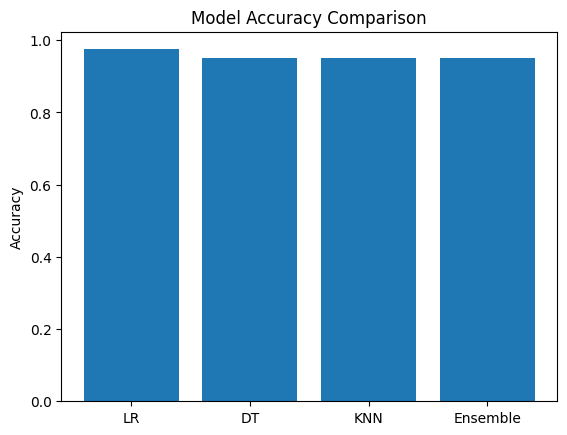

In [ ]:
import matplotlib.pyplot as plt

models = ["LR","DT","KNN","Ensemble"]
accuracies = [lr_acc, dt_acc, knn_acc, ensemble_acc]

plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

**K-Fold Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

**Model Building & Evaluation For K-Fold Cross Validation**


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(max_depth=5)
knn = KNeighborsClassifier()

ensemble = VotingClassifier(
    estimators=[("lr", lr), ("dt", dt), ("knn", knn)],
    voting="hard"
)

In [ ]:
lr_scores = cross_val_score(lr, X, y, cv=kfold)
dt_scores = cross_val_score(dt, X, y, cv=kfold)
knn_scores = cross_val_score(knn, X, y, cv=kfold)
ens_scores = cross_val_score(ensemble, X, y, cv=kfold)

In [ ]:
print("LR Accuracy:", lr_scores.mean())
print("DT Accuracy:", dt_scores.mean())
print("KNN Accuracy:", knn_scores.mean())
print("Ensemble Accuracy:", ens_scores.mean())

LR Accuracy: 0.96
DT Accuracy: 0.96
KNN Accuracy: 0.9299999999999999
Ensemble Accuracy: 0.9550000000000001


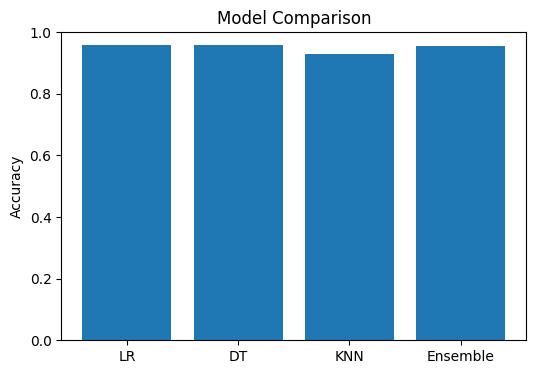

In [ ]:
plt.figure(figsize=(6,4))

models = ['LR', 'DT', 'KNN', 'Ensemble']
accuracies = [
    lr_scores.mean(),
    dt_scores.mean(),
    knn_scores.mean(),
    ens_scores.mean()
]

plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)



plt.show()

**Data Visualization**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
cr_expanded['Purchase_Label'] = cr_expanded['Purchase_Decision'].map({
    1: 'Buy',
    0: 'Not Buy'
})

Purchase_Decision          0           1
Gender                                  
0                   0.000000  100.000000
1                  11.347518   88.652482


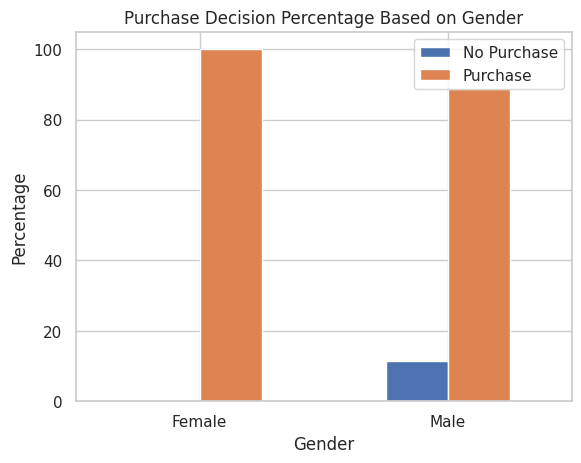

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Calculate percentage
gender_purchase = pd.crosstab(
    cr_expanded["Gender"],
    cr_expanded["Purchase_Decision"],
    normalize="index"
) * 100

print(gender_purchase)

# Plot
gender_purchase.plot(kind="bar")

plt.xticks([0,1], ["Female","Male"], rotation=0)

plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.title("Purchase Decision Percentage Based on Gender")

plt.legend(["No Purchase","Purchase"])

plt.show()

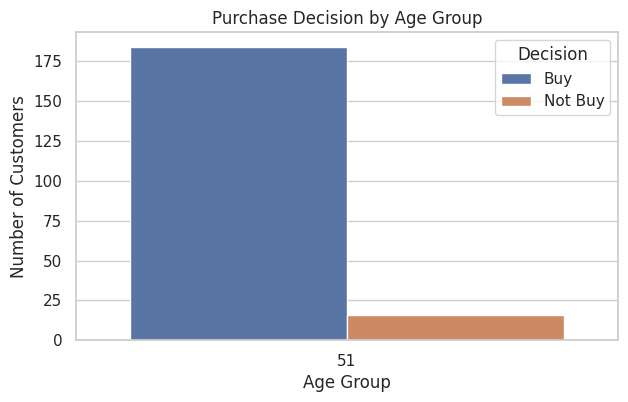

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=cr_expanded,
    x='Age_Group',
    hue='Purchase_Label'
)
plt.title("Purchase Decision by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.legend(title="Decision")
plt.show()

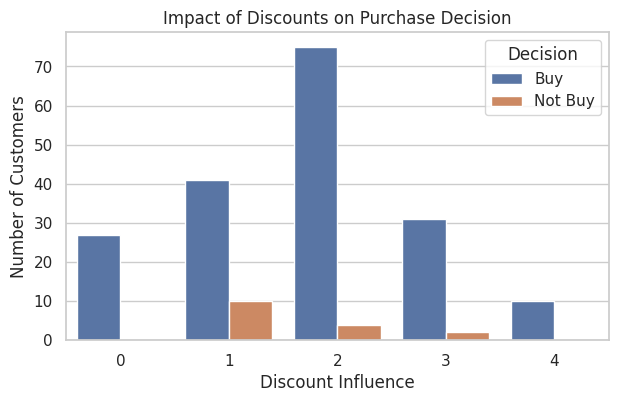

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=cr_expanded,
    x='Discount_Influence',
    hue='Purchase_Label'
)
plt.title("Impact of Discounts on Purchase Decision")
plt.xlabel("Discount Influence")
plt.ylabel("Number of Customers")
plt.legend(title="Decision")
plt.show()

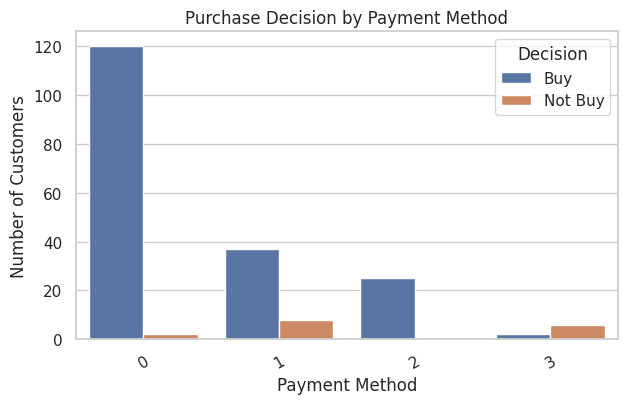

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=cr_expanded,
    x='Payment_Method',
    hue='Purchase_Label'
)
plt.title("Purchase Decision by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.legend(title="Decision")
plt.show()

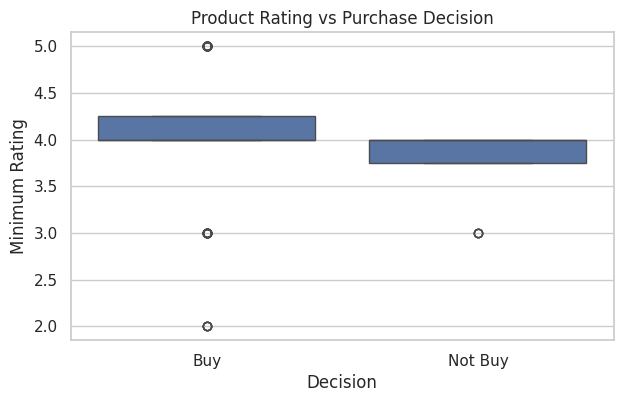

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(
    data=cr_expanded,
    x='Purchase_Label',
    y='Min_Rating'
)
plt.title("Product Rating vs Purchase Decision")
plt.xlabel("Decision")
plt.ylabel("Minimum Rating")
plt.show()

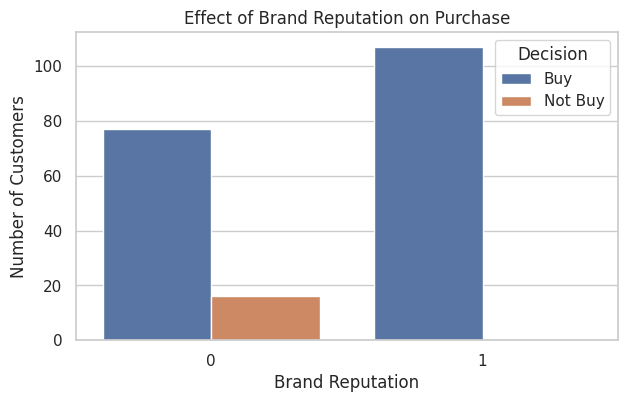

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(
    data=cr_expanded,
    x='Brand reputation',
    hue='Purchase_Label'
)
plt.title("Effect of Brand Reputation on Purchase")
plt.xlabel("Brand Reputation")
plt.ylabel("Number of Customers")
plt.legend(title="Decision")
plt.show()

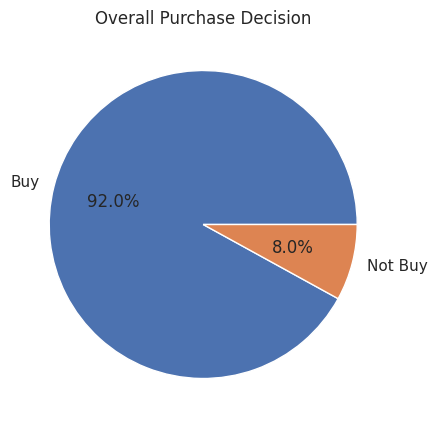

In [ ]:
plt.figure(figsize=(5,5))
cr_expanded['Purchase_Label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Overall Purchase Decision")
plt.ylabel('')
plt.show()